# HW-NAS-Bench-360 API Showcase

This notebook walks through the main functions in `api.py`. The dataset covers **15 625 NB201 architectures** benchmarked across three tasks (`cifar100`, `darcy`, `ninapro`), three devices (`jetson`, `pi5`, `pixel`), and up to three inference frameworks (`onnx`, `litert`, `torchmobile`).

In [1]:
import api
import matplotlib.pyplot as plt

## 1. Loading the dataset

`load()` returns the full dataset as a DataFrame. Each row is one (architecture, task, framework, device) combination.

In [2]:
df = api.load()
print(f"{len(df):,} rows, {df['arch_idx'].nunique():,} architectures")
df.head()

328,125 rows, 15,625 architectures


,arch_idx,device,framework,task,lat_ms,lat_ms_var,energy_mj,accuracy
0,0,jetson,onnx,cifar100,11.885932,0.008609,17.131142,52.913333
1,0,jetson,onnx,darcy,13.379207,0.000810,58.056532,0.070820
2,0,jetson,onnx,ninapro,11.943303,0.011336,16.339993,90.743551
3,0,pi5,litert,cifar100,1.487672,0.000123,2.575322,52.913333
4,0,pi5,litert,darcy,11.607917,0.000368,20.345979,0.070820


## 2. Single-architecture lookup

`query()` fetches one row by exact (arch_idx, task, framework, device) and returns it as a plain dict.

In [3]:
api.query(0, "cifar100", "litert", "pi5")

{'arch_idx': 0,
 'device': 'pi5',
 'framework': 'litert',
 'task': 'cifar100',
 'lat_ms': 1.487672,
 'lat_ms_var': 0.000123415759666,
 'energy_mj': 2.575322,
 'accuracy': 52.913333294677734}

## 3. Querying all architectures for a slice

`query_task()` returns every architecture measured on a given (task, framework, device) combination.

In [3]:
slice_df = api.query_task("cifar100", "litert", "pi5")
print(f"{len(slice_df)} architectures")
slice_df[["lat_ms", "energy_mj", "accuracy"]].describe()

15625 architectures


,lat_ms,energy_mj,accuracy
count,15625.000000,15625.000000,15625.000000
mean,3.437057,5.392683,61.387852
std,2.122983,3.257704,12.172301
min,0.003055,0.000969,1.000000
25%,1.449930,2.362147,59.190000
50%,3.261494,5.183446,65.273333
75%,5.145052,7.913649,67.873333
max,13.367487,19.500113,73.513333


Latency distribution across all architectures on this slice.

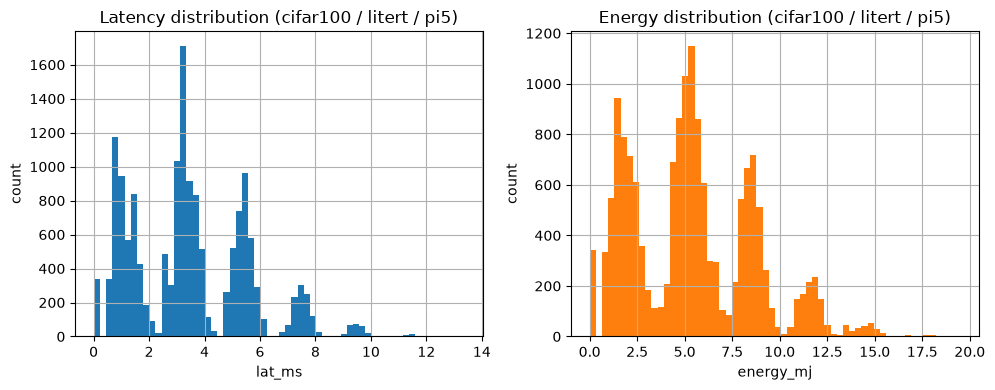

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

slice_df["lat_ms"].hist(bins=60, ax=axes[0])
axes[0].set(title="Latency distribution (cifar100 / litert / pi5)",
            xlabel="lat_ms", ylabel="count")

slice_df["energy_mj"].hist(bins=60, ax=axes[1], color="tab:orange")
axes[1].set(title="Energy distribution (cifar100 / litert / pi5)",
            xlabel="energy_mj", ylabel="count")

plt.tight_layout()
plt.show()

## 4. Aggregation

`aggregate()` groups the dataset by any combination of columns and computes summary statistics for a chosen metric.

In [6]:
api.aggregate(by=("device", "framework", "task"), metric="lat_ms")

,device,framework,task,min,median,max
0,jetson,onnx,cifar100,3.624408,13.259382,24.370721
1,jetson,onnx,darcy,4.487012,19.330181,36.168658
2,jetson,onnx,ninapro,3.787717,12.949164,22.534976
3,pi5,litert,cifar100,0.003055,3.261494,13.367487
4,pi5,litert,darcy,0.003667,24.171290,98.418231
5,pi5,litert,ninapro,0.002907,2.634430,10.836039
6,pi5,onnx,cifar100,0.812746,4.964793,20.054671
7,pi5,onnx,darcy,5.318231,35.278108,138.339743
8,pi5,onnx,ninapro,0.720679,4.535190,18.616759
9,pi5,torchmobile,cifar100,1.001088,7.919581,17.164752


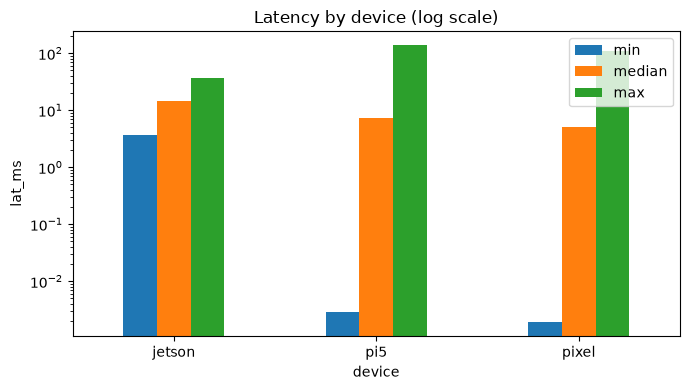

In [7]:
agg = api.aggregate(by=("device",), metric="lat_ms", agg=("min", "median", "max"))

agg.set_index("device")[["min", "median", "max"]].plot(
    kind="bar", figsize=(7, 4), logy=True
)
plt.title("Latency by device (log scale)")
plt.ylabel("lat_ms")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 5. Pareto front

`get_pareto_front()` returns the non-dominated architectures for a given slice. By default it minimises `lat_ms` and `energy_mj` while maximising `accuracy`. For the `darcy` task, accuracy is a relative L2 error (lower is better), so it is automatically moved to the minimise set.

In [8]:
pareto = api.get_pareto_front("cifar100", "pi5", "litert")
print(f"{len(pareto)} pareto-optimal architectures out of {len(slice_df)}")
pareto[["arch_idx", "lat_ms", "energy_mj", "accuracy"]].head(10)

37 pareto-optimal architectures out of 15625


,arch_idx,lat_ms,energy_mj,accuracy
0,552,0.003055,0.000969,1.00
1,3095,0.003055,0.000969,1.00
2,9438,0.003055,0.000969,1.00
3,10913,0.003055,0.000969,1.00
4,8912,0.496406,0.833825,59.20
5,11241,0.496443,0.803761,59.18
6,15183,0.766462,1.293249,63.46
7,15137,0.766827,1.216405,63.16
8,712,0.768258,1.201903,63.14
9,8520,0.830646,1.427322,64.76


Scatter plot of all architectures with the Pareto front highlighted.

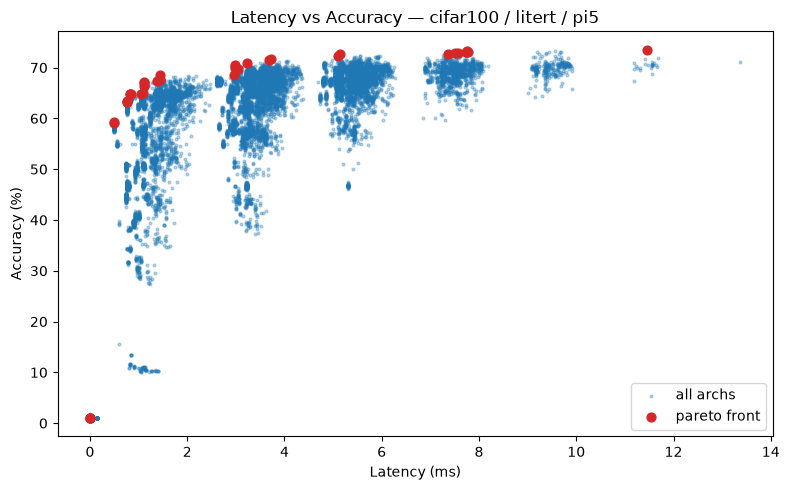

In [9]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.scatter(slice_df["lat_ms"], slice_df["accuracy"],
           s=4, alpha=0.3, label="all archs")
ax.scatter(pareto["lat_ms"], pareto["accuracy"],
           s=40, color="tab:red", zorder=3, label="pareto front")

ax.set(xlabel="Latency (ms)", ylabel="Accuracy (%)",
       title="Latency vs Accuracy — cifar100 / litert / pi5")
ax.legend()
plt.tight_layout()
plt.show()